# 08. Compare Algorithms

This notebook compares K-Means, DBSCAN, and Isolation Forest with graph features.


## 1. Imports and paths


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

RESULTS_DIR = Path("../results")
DATA_DIR = Path("../datasets")
CSV_DIR = RESULTS_DIR / "csv"
FIGURE_DIR = RESULTS_DIR / "figures"
PROCESSED_DIR = DATA_DIR / "processed"

KMEANS_PATH = CSV_DIR / "kmeans_clustered_users.csv"
DBSCAN_PATH = CSV_DIR / "dbscan_clustered_users.csv"
ISOLATION_PATH = CSV_DIR / "isolation_forest_results.csv"
COMPARISON_PATH = CSV_DIR / "algorithm_comparison.csv"
DETAILED_COMPARISON_PATH = CSV_DIR / "algorithm_comparison_detailed.csv"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 2. Load outputs from all three algorithms


In [2]:
kmeans_result = pd.read_csv(KMEANS_PATH)
dbscan_result = pd.read_csv(DBSCAN_PATH)
isolation_result = pd.read_csv(ISOLATION_PATH)

print("K-Means:", kmeans_result.shape)
print("DBSCAN:", dbscan_result.shape)
print("Isolation Forest:", isolation_result.shape)

isolation_result.head()


K-Means: (50000, 14)
DBSCAN: (50000, 13)
Isolation Forest: (50000, 30)


,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label,degree,degree_centrality,clustering_coefficient,interaction_score,pagerank,isolation_score,anomaly_score,anomaly_label,suspicious_score,final_anomaly_score,final_anomaly_label,is_anomaly,high_hashtag_count,high_hashtag_ratio,high_mention_count,high_retweet_count,high_retweet_to_follower,low_follower_high_activity,high_graph_interaction
0,132131,85,1,2353,0,83,5,0,0,1114,1,11,0.00022,0.145455,0.004391,0.000019,0.322318,0.322318,1,0.000000,0.225622,1,0,0,0,0,0,0,0,0
1,289683,55,5,9617,1,77,14,2,1,186,0,10,0.00020,0.177778,0.003366,0.000016,0.196504,0.196504,1,0.166667,0.187553,1,0,0,0,1,0,0,0,0
2,779715,6,2,4363,1,61,10,2,1,296,0,9,0.00018,0.166667,0.002577,0.000014,0.075022,0.075022,1,0.000000,0.052515,1,0,0,0,0,0,0,0,0
3,696168,54,5,2242,1,49,6,4,1,654,1,13,0.00026,0.102564,0.005319,0.000020,0.185068,0.185068,1,0.166667,0.179548,1,0,0,0,1,0,0,0,0
4,704441,26,3,8438,0,29,6,2,1,1142,1,11,0.00022,0.127273,0.004037,0.000017,0.228997,0.228997,1,0.000000,0.160298,1,0,0,0,0,0,0,0,0


## 3. Normalize anomaly labels for comparison


In [3]:
algorithm_outputs = {
    "K-Means": kmeans_result.copy(),
    "DBSCAN": dbscan_result.copy(),
    "Isolation Forest": isolation_result.copy(),
}

for name, df in algorithm_outputs.items():
    if "is_anomaly" not in df.columns:
        if "anomaly_label" in df.columns:
            df["is_anomaly"] = (df["anomaly_label"] == -1).astype(int)
        elif "cluster" in df.columns:
            df["is_anomaly"] = (df["cluster"] == -1).astype(int)
        else:
            raise ValueError(f"{name} has no compatible anomaly column.")
    algorithm_outputs[name] = df

summary_rows = []
for name, df in algorithm_outputs.items():
    summary_rows.append({
        "algorithm": name,
        "total_users": len(df),
        "anomaly_users": int(df["is_anomaly"].sum()),
        "normal_users": int((df["is_anomaly"] == 0).sum()),
        "anomaly_ratio": round(df["is_anomaly"].mean() * 100, 2),
    })

comparison_summary = pd.DataFrame(summary_rows)
comparison_summary


,algorithm,total_users,anomaly_users,normal_users,anomaly_ratio
0,K-Means,50000,2500,47500,5.00
1,DBSCAN,50000,2816,47184,5.63
2,Isolation Forest,50000,2500,47500,5.00


## 4. Supervised metrics when `bot_label` exists


In [4]:
metric_rows = []
confusion_matrices = {}

for name, df in algorithm_outputs.items():
    row = comparison_summary[comparison_summary["algorithm"] == name].iloc[0].to_dict()
    if "bot_label" in df.columns:
        y_true = df["bot_label"].astype(int)
        y_pred = df["is_anomaly"].astype(int)
        row.update({
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1_score": f1_score(y_true, y_pred, zero_division=0),
        })
        confusion_matrices[name] = confusion_matrix(y_true, y_pred)
    metric_rows.append(row)

detailed_comparison = pd.DataFrame(metric_rows)
detailed_comparison


,algorithm,total_users,anomaly_users,normal_users,anomaly_ratio,accuracy,precision,recall,f1_score
0,K-Means,50000,2500,47500,5.00,0.50128,0.516400,0.051603,0.093829
1,DBSCAN,50000,2816,47184,5.63,0.49996,0.502841,0.056599,0.101746
2,Isolation Forest,50000,2500,47500,5.00,0.49984,0.502000,0.050164,0.091213


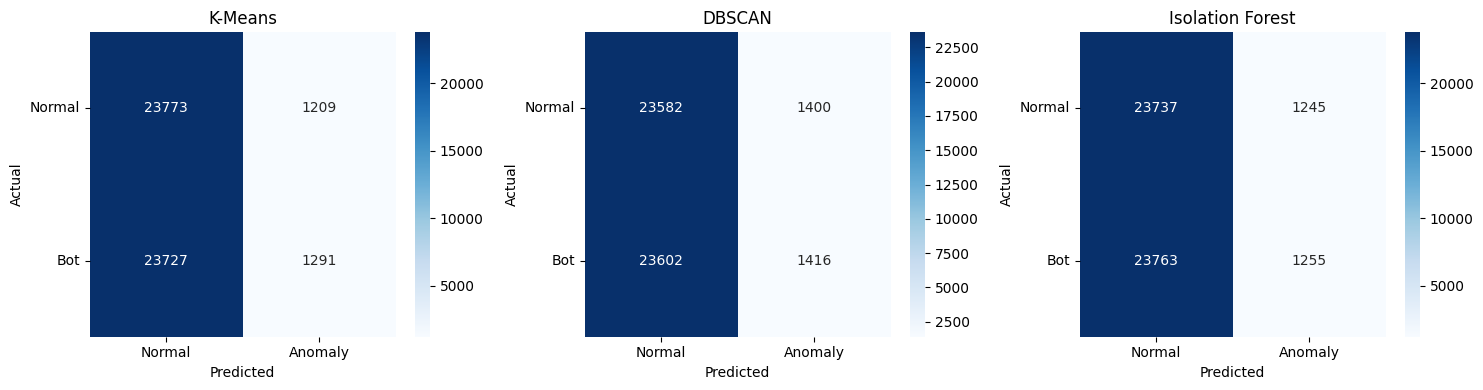

In [5]:
if confusion_matrices:
    fig, axes = plt.subplots(1, len(confusion_matrices), figsize=(5 * len(confusion_matrices), 4))
    if len(confusion_matrices) == 1:
        axes = [axes]
    for ax, (name, cm) in zip(axes, confusion_matrices.items()):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticklabels(["Normal", "Anomaly"])
        ax.set_yticklabels(["Normal", "Bot"], rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "compare_confusion_matrices.png", dpi=150)
    plt.show()
else:
    print("No true label available for confusion matrix.")


## 5. Unsupervised metrics: silhouette and anomaly distribution


In [6]:
feature_cols = [
    "retweet_count",
    "mention_count",
    "follower_count",
    "verified",
    "tweet_length",
    "username_length",
    "hashtag_count",
    "has_hashtag",
    "account_age_days",
]

silhouette_rows = []
for name, df in algorithm_outputs.items():
    available_cols = [col for col in feature_cols if col in df.columns]
    labels = None
    if "cluster" in df.columns and df["cluster"].nunique() > 1:
        labels = df["cluster"]
    elif df["is_anomaly"].nunique() > 1:
        labels = df["is_anomaly"]

    score = np.nan
    if labels is not None:
        sample_df = df[available_cols].fillna(0)
        sample_size = min(8000, len(sample_df))
        sampled_idx = sample_df.sample(sample_size, random_state=RANDOM_STATE).index
        sampled_X = StandardScaler().fit_transform(sample_df.loc[sampled_idx])
        sampled_labels = labels.loc[sampled_idx]
        if sampled_labels.nunique() > 1:
            score = silhouette_score(sampled_X, sampled_labels)
    silhouette_rows.append({"algorithm": name, "silhouette_score": score})

silhouette_df = pd.DataFrame(silhouette_rows)
detailed_comparison = detailed_comparison.merge(silhouette_df, on="algorithm", how="left")
detailed_comparison


,algorithm,total_users,anomaly_users,normal_users,anomaly_ratio,accuracy,precision,recall,f1_score,silhouette_score
0,K-Means,50000,2500,47500,5.00,0.50128,0.516400,0.051603,0.093829,0.151387
1,DBSCAN,50000,2816,47184,5.63,0.49996,0.502841,0.056599,0.101746,0.124000
2,Isolation Forest,50000,2500,47500,5.00,0.49984,0.502000,0.050164,0.091213,0.042436


## 6. Algorithm comparison visualizations


C:\Users\Danh\AppData\Local\Temp\ipykernel_17924\159601254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_summary, x="algorithm", y="anomaly_users", palette="Set2")


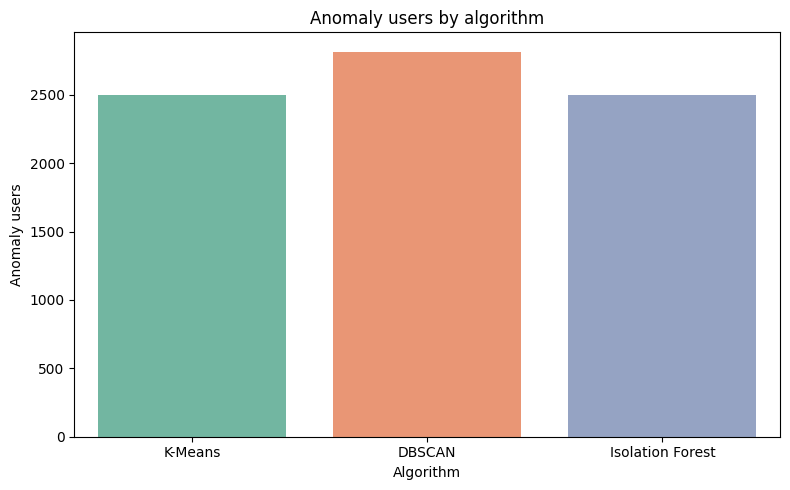

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_summary, x="algorithm", y="anomaly_users", palette="Set2")
plt.title("Anomaly users by algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Anomaly users")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_algorithms_anomaly_users.png", dpi=150)
plt.show()


C:\Users\Danh\AppData\Local\Temp\ipykernel_17924\2865266079.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_summary, x="algorithm", y="anomaly_ratio", palette="Set3")


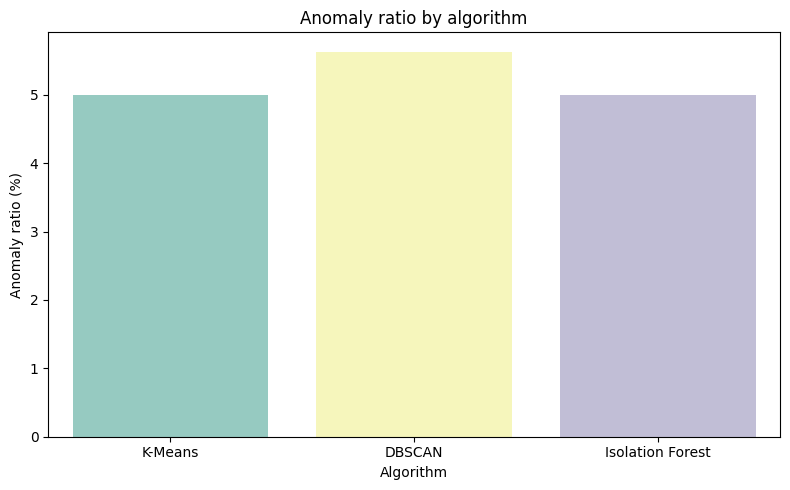

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_summary, x="algorithm", y="anomaly_ratio", palette="Set3")
plt.title("Anomaly ratio by algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Anomaly ratio (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_algorithms_anomaly_ratio.png", dpi=150)
plt.show()


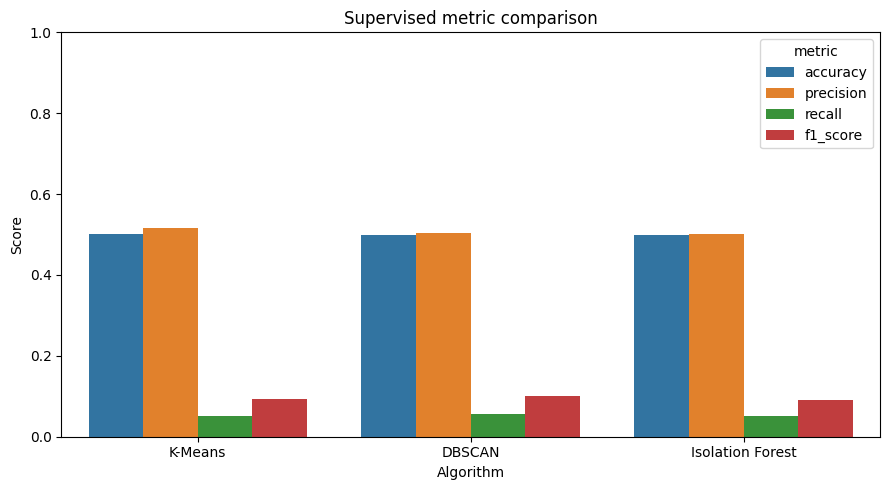

In [9]:
if "f1_score" in detailed_comparison.columns:
    metric_plot = detailed_comparison.melt(
        id_vars="algorithm",
        value_vars=[col for col in ["accuracy", "precision", "recall", "f1_score"] if col in detailed_comparison.columns],
        var_name="metric",
        value_name="score",
    )
    plt.figure(figsize=(9, 5))
    sns.barplot(data=metric_plot, x="algorithm", y="score", hue="metric")
    plt.title("Supervised metric comparison")
    plt.xlabel("Algorithm")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "compare_algorithms_metrics.png", dpi=150)
    plt.show()


C:\Users\Danh\AppData\Local\Temp\ipykernel_17924\2276123772.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=detailed_comparison, x="algorithm", y="silhouette_score", palette="muted")


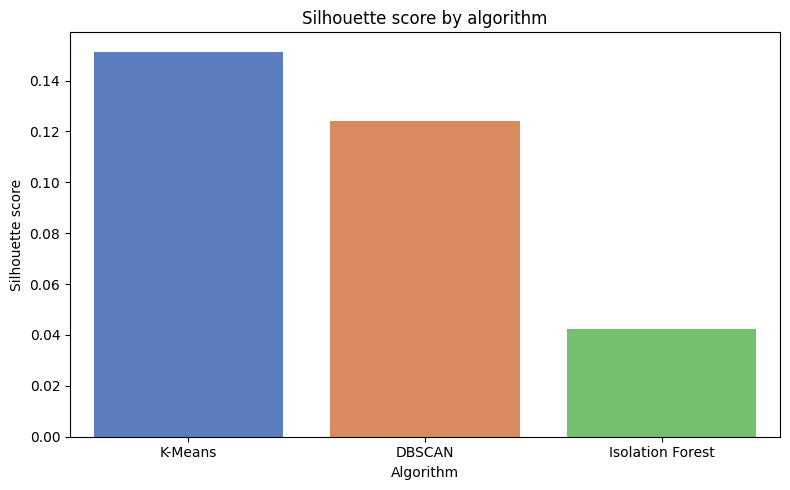

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(data=detailed_comparison, x="algorithm", y="silhouette_score", palette="muted")
plt.title("Silhouette score by algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_algorithms_silhouette.png", dpi=150)
plt.show()


## 7. PCA anomaly visualization for all algorithms


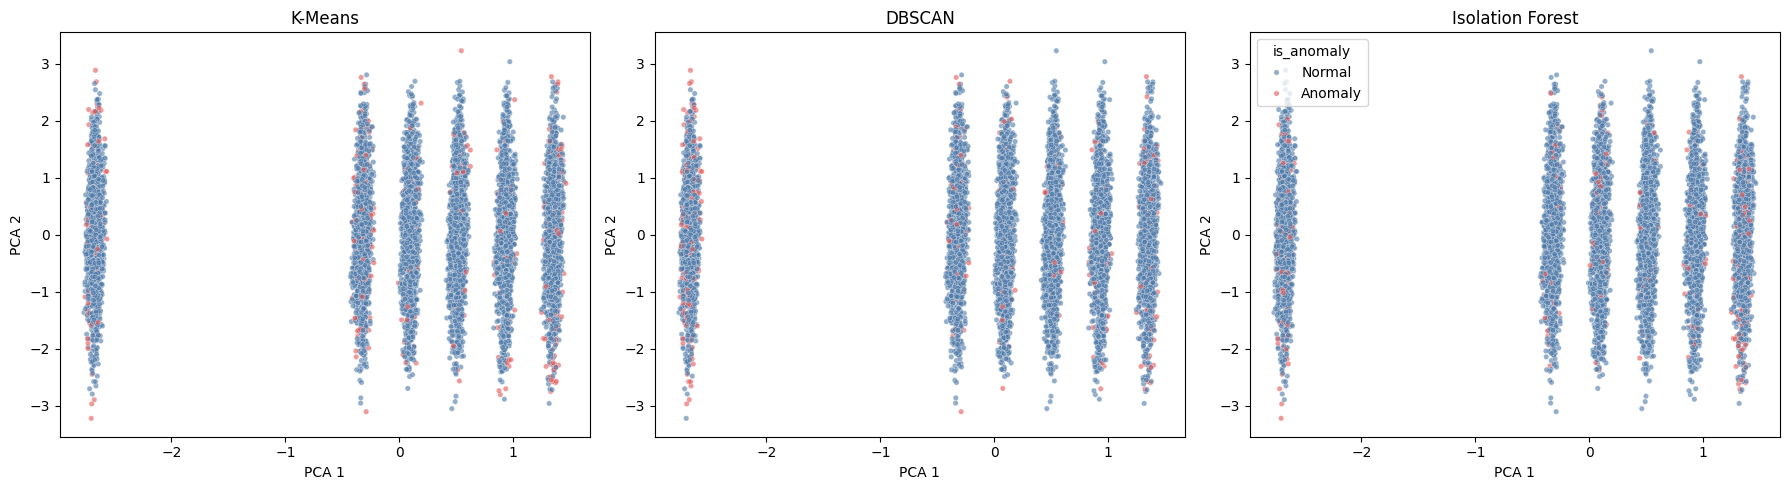

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, algorithm_outputs.items()):
    available_cols = [col for col in feature_cols if col in df.columns]
    sample = df.sample(min(8000, len(df)), random_state=RANDOM_STATE).copy()
    X = StandardScaler().fit_transform(sample[available_cols].fillna(0))
    pca_points = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
    plot_df = pd.DataFrame({
        "pca_1": pca_points[:, 0],
        "pca_2": pca_points[:, 1],
        "is_anomaly": sample["is_anomaly"].map({0: "Normal", 1: "Anomaly"}).values,
    })
    sns.scatterplot(
        data=plot_df,
        x="pca_1",
        y="pca_2",
        hue="is_anomaly",
        palette={"Normal": "#4C78A8", "Anomaly": "#E45756"},
        s=15,
        alpha=0.6,
        ax=ax,
        legend=(name == "Isolation Forest"),
    )
    ax.set_title(name)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_algorithms_pca_anomaly.png", dpi=150)
plt.show()


## 8. Save comparison tables


In [12]:
comparison_summary.to_csv(COMPARISON_PATH, index=False)
detailed_comparison.to_csv(DETAILED_COMPARISON_PATH, index=False)

print("Updated:", COMPARISON_PATH)
print("Saved:", DETAILED_COMPARISON_PATH)
detailed_comparison


Updated: ..\results\csv\algorithm_comparison.csv
Saved: ..\results\csv\algorithm_comparison_detailed.csv


,algorithm,total_users,anomaly_users,normal_users,anomaly_ratio,accuracy,precision,recall,f1_score,silhouette_score
0,K-Means,50000,2500,47500,5.00,0.50128,0.516400,0.051603,0.093829,0.151387
1,DBSCAN,50000,2816,47184,5.63,0.49996,0.502841,0.056599,0.101746,0.124000
2,Isolation Forest,50000,2500,47500,5.00,0.49984,0.502000,0.050164,0.091213,0.042436


## 9. Summary

Isolation Forest is the upgraded method because it uses both old behavior features and new graph features. K-Means and DBSCAN remain useful baselines.
